## Targeted Password Guessing with Prompt Evolution for PassLLM

### Install dependencies

In [ ]:
!pip install -U transformers

In [3]:
!pip install -q openevolve transformers peft accelerate pyyaml flask nest_asyncio matplotlib

### Setup Kaggle and download data

In [1]:
import os
import sys

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
src_config = 'kaggle.json'
dst_config = os.path.join(kaggle_dir, 'kaggle.json')

if os.path.exists(src_config):
    import shutil
    if os.path.abspath(src_config) != os.path.abspath(dst_config):
        shutil.copy(src_config, dst_config)
    if os.name != 'nt':
        os.chmod(dst_config, 0o600)
    print("OK")
else:
    print('kaggle.json not found')

OK


In [ ]:
!apt-get update
!apt-get install -y unzip
!pip install -q kaggle
!mkdir -p /content/data
!chmod 777 /content/data
!kaggle competitions download -c password-guessing -p /content/data --force
!unzip -q -o /content/data/password-guessing.zip -d /content/data

### Environment constants and GPU check

In [2]:
import multiprocessing
try:
    multiprocessing.set_start_method("spawn", force=True)
except RuntimeError:
    pass

import os
import json
import torch

COMPETITION = "/content/data"
PATH_TRAIN = os.path.join(COMPETITION, "train.json")
PATH_ADAPTER_126_CSDN = os.path.join(COMPETITION, "126_csdn_disQwen0.5B", "126_csdn_disQwen0.5B")
BASE_MODEL_PASSLLM = "Qwen/Qwen2.5-0.5B-Instruct"

EXPERIMENT_DIR = os.path.join(os.getcwd(), "targeted_evolution_exp")
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

os.environ["PASSLLM_COMPETITION"] = COMPETITION
os.environ["PASSLLM_TRAIN"] = PATH_TRAIN
os.environ["PASSLLM_ADAPTER_126_CSDN"] = PATH_ADAPTER_126_CSDN
os.environ["PASSLLM_BASE_MODEL"] = BASE_MODEL_PASSLLM
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print("COMPETITION:", COMPETITION)
print("PATH_TRAIN:", PATH_TRAIN)
print("PATH_ADAPTER_126_CSDN:", PATH_ADAPTER_126_CSDN)
print("EXPERIMENT_DIR:", EXPERIMENT_DIR)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CPU mode")

COMPETITION: /content/data
PATH_TRAIN: /content/data/train.json
PATH_ADAPTER_126_CSDN: /content/data/126_csdn_disQwen0.5B/126_csdn_disQwen0.5B
EXPERIMENT_DIR: /root/targeted_evolution_exp
GPU: NVIDIA GeForce RTX 5090


In [3]:
with open(PATH_TRAIN, "r", encoding="utf-8") as f:
    TRAIN_DATA = json.load(f)
if isinstance(TRAIN_DATA, dict):
    TRAIN_DATA = [TRAIN_DATA]
print("Train samples:", len(TRAIN_DATA))
if TRAIN_DATA:
    print("Example:", TRAIN_DATA[0])

Train samples: 16000
Example: {'Knowledge': {'Old password': '225654314'}, 'password': '225654314'}


### Password length distribution

Total: 16000
Mean: 8.84
Std: 2.73
1σ: [6.11, 11.57]
2σ: [3.38, 14.31]


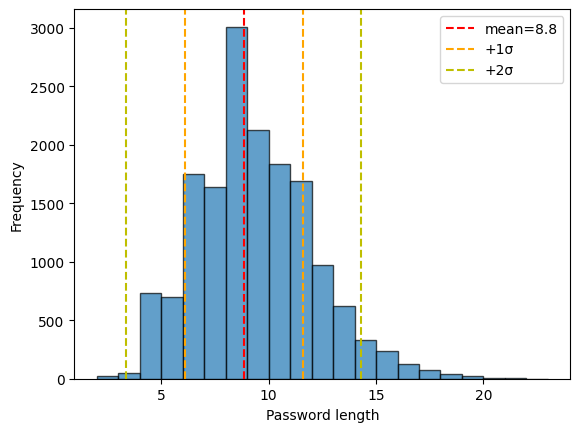

In [4]:
import numpy as np
import matplotlib.pyplot as plt

lengths = []
for item in TRAIN_DATA:
    pwd = item.get("password")
    if pwd and isinstance(pwd, str):
        lengths.append(len(pwd))

lengths = np.array(lengths)
mean = np.mean(lengths)
std = np.std(lengths)

print(f"Total: {len(lengths)}")
print(f"Mean: {mean:.2f}")
print(f"Std: {std:.2f}")
print(f"1σ: [{mean-std:.2f}, {mean+std:.2f}]")
print(f"2σ: [{mean-2*std:.2f}, {mean+2*std:.2f}]")

plt.hist(lengths, bins=21, alpha=0.7, edgecolor='black')
plt.axvline(mean, color='r', linestyle='dashed', label=f'mean={mean:.1f}')
plt.axvline(mean+std, color='orange', linestyle='dashed', label='+1σ')
plt.axvline(mean-std, color='orange', linestyle='dashed')
plt.axvline(mean+2*std, color='y', linestyle='dashed', label='+2σ')
plt.axvline(mean-2*std, color='y', linestyle='dashed')
plt.xlabel("Password length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Evolution config and initial prompt

In [5]:
CONFIG_YAML = '''
llm:
  models:
    - name: openai/gpt-oss-120b
      api_base: https://api.zveno.ai/v1
      api_key: "YOUR_TOKEN"
      api_type: openai
      default_params:
        temperature: 1.0
        top_p: 0.95
        max_tokens: 10000
        presence_penalty: 0 # 0.5

evolution:
  generations: 100
  population_size: 2000
  elitism: 10

operators:
  mutation:
    type: llm
    llm_model: openai/gpt-oss-120b
    prompt_template: |
      You are improving a prompt for targeted password guessing.
      A prompt is always a text instruction, not program code.
      Current prompt:
      """{program}"""
      Its crack rate on the training data is {score:.4f}.
      Propose a modified prompt that increases the crack rate.
      You may change wording, add constraints, remove ineffective parts, or introduce new heuristics.
      Output only the new prompt text, nothing else.
  crossover:
    type: llm
    llm_model: openai/gpt-oss-120b
    probability: 0.8
    prompt_template: |
      Combine two prompts to create a superior one.
      Prompt A (score {score_a:.4f}): """{program_a}"""
      Prompt B (score {score_b:.4f}): """{program_b}"""
      Output only the new prompt.

selection:
  type: tournament
  tournament_size: 5
'''

config_path = os.path.join(EXPERIMENT_DIR, "config_evolution.yaml")
with open(config_path, "w", encoding="utf-8") as f:
    f.write(CONFIG_YAML.strip())
print("Config saved:", config_path)

Config saved: /root/targeted_evolution_exp/config_evolution.yaml


In [6]:
INITIAL_PROMPT = """You are a password guessing model. Given the old password, generate one possible new password. Output only the password."""

initial_prompt_path = os.path.join(EXPERIMENT_DIR, "initial_prompt.txt")
with open(initial_prompt_path, "w", encoding="utf-8") as f:
    f.write(INITIAL_PROMPT)
print("Initial prompt saved:", initial_prompt_path)

Initial prompt saved: /root/targeted_evolution_exp/initial_prompt.txt


In [7]:
best_path = os.path.join(EXPERIMENT_DIR, "best_program.txt")
with open(initial_prompt_path, "r", encoding="utf-8") as src:
    initial_content = src.read()
with open(best_path, "w", encoding="utf-8") as dst:
    dst.write(initial_content)
print(f"Initial prompt written to {best_path}")

Initial prompt written to /root/targeted_evolution_exp/best_program.txt


### Core module passllm_core.py

In [8]:
%%writefile passllm_core.py
import os
import json
import torch
import subprocess
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

def get_gpu_memory():
    try:
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=memory.used,memory.total,utilization.gpu', '--format=csv,noheader,nounits'],
            capture_output=True, text=True, check=True
        )
        used, total, util = result.stdout.strip().split(', ')
        return f"GPU util: {util}%, VRAM: {used}/{total} MiB"
    except:
        return "GPU stats unavailable"

def load_model():
    base_model_name = os.environ.get("PASSLLM_BASE_MODEL", "Qwen/Qwen2.5-0.5B-Instruct")
    adapter_path = os.environ.get("PASSLLM_ADAPTER_126_CSDN", "")
    tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
    tokenizer.pad_token_id = tokenizer.eos_token_id
    tokenizer.padding_side = "left"

    model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        trust_remote_code=True,
    )

    if adapter_path and os.path.exists(adapter_path):
        print(f"[INFO] Loading adapter from {adapter_path}")
        model = PeftModel.from_pretrained(model, adapter_path, is_trainable=False)
        model = model.merge_and_unload()
        print("[INFO] Adapter merged.")
    else:
        print("[WARNING] No adapter found.")

    model.eval()
    model = torch.compile(model, mode="reduce-overhead", fullgraph=False)
    return model, tokenizer

def generate_candidates_batch(old_passwords, prompt_template, model, tokenizer,
                              target_count=100, gen_multiplier=1.0, batch_size=32, show_progress=True):
    generation_count = int(target_count * gen_multiplier)
    results = [None] * len(old_passwords)

    prompts = []
    for old in old_passwords:
        messages = [
            {"role": "system", "content": prompt_template.strip()},
            {"role": "user", "content": f"Old password: {old}"}
        ]
        full_input = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        prompts.append(full_input)

    iterator = range(0, len(prompts), batch_size)
    if show_progress:
        from tqdm import tqdm
        iterator = tqdm(iterator, desc="Generating batches", unit="batch")

    for batch_idx, start in enumerate(iterator):
        end = min(start + batch_size, len(prompts))
        batch = prompts[start:end]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(model.device)

        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=32,
                do_sample=True,
                temperature=0.9,
                top_p=0.95,
                num_return_sequences=generation_count,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
                use_cache=True
            )

        for i in range(len(batch)):
            seqs = outputs[i * generation_count:(i+1) * generation_count]
            candidates = []
            for seq in seqs:
                gen_text = tokenizer.decode(seq[inputs['input_ids'][i].shape[0]:], skip_special_tokens=True)
                guess = gen_text.split("\n")[0].strip().strip('"').strip("'")
                if guess.lower().startswith("password:"):
                    guess = guess[9:].strip()
                if guess:
                    candidates.append(guess[:64])
            unique = []
            seen = set()
            for c in candidates:
                if c not in seen:
                    seen.add(c)
                    unique.append(c)
                if len(unique) == target_count:
                    break
            if len(unique) < target_count:
                import random, string
                chars = string.ascii_letters + string.digits + "!@#$%&*"
                old = old_passwords[start + i]
                for _ in range(target_count - len(unique)):
                    unique.append(old + random.choice(chars))
            results[start + i] = unique

        first_idx = start
        print(f"\nBatch {batch_idx}: old={old_passwords[first_idx]}")
        print(f"  First 20 candidates: {results[first_idx][:20]}")
        print(get_gpu_memory())
        print()

        if show_progress:
            iterator.set_postfix_str(get_gpu_memory())

    return results

def generate_candidates_single(old_password, prompt_template, model, tokenizer,
                               target_count=100, gen_multiplier=1.0):
    return generate_candidates_batch([old_password], prompt_template, model, tokenizer,
                                     target_count, gen_multiplier, batch_size=1, show_progress=False)[0]

def compute_crack_rate(valid_items, prompt_template, model, tokenizer,
                       sample_size=200, num_candidates=20, gen_multiplier=1.0, batch_size=15):
    indices = torch.randperm(len(valid_items))[:sample_size].tolist()
    sample_items = [valid_items[i] for i in indices]
    
    old_list = []
    target_list = []
    for item in sample_items:
        old = (item.get("Knowledge") or {}).get("Old password")
        target = item.get("password")
        if old and target:
            old_list.append(old)
            target_list.append(target)
    
    if not old_list:
        return 0.0
    
    candidates_batch = generate_candidates_batch(
        old_list, prompt_template, model, tokenizer,
        target_count=num_candidates, gen_multiplier=gen_multiplier,
        batch_size=batch_size, show_progress=True
    )
    
    correct = 0
    for i, cands in enumerate(candidates_batch):
        if target_list[i] in cands:
            correct += 1
    
    rate = correct / len(old_list)
    print(f"Evaluation: {correct}/{len(old_list)} correct. Crack Rate: {rate:.4f}")
    return rate

Overwriting passllm_core.py


### Evaluator script for OpenEvolve

In [9]:
os.environ["PASSLLM_EVAL_SAMPLE_SIZE"] = "500"
os.environ["PASSLLM_EVAL_NUM_CANDIDATES"] = "100"
os.environ["PASSLLM_EVAL_GEN_MULTIPLIER"] = "1.0"

In [10]:
%%writefile evaluator.py
import os
import sys
import json
import torch
sys.path.append(os.getcwd())
from passllm_core import load_model, compute_crack_rate

PATH_TRAIN = os.environ.get("PASSLLM_TRAIN", "")
if not PATH_TRAIN:
    print("Error: PASSLLM_TRAIN not set", file=sys.stderr)
    sys.exit(1)

SAMPLE_SIZE = int(os.environ.get("PASSLLM_EVAL_SAMPLE_SIZE", "500"))
NUM_CANDIDATES = int(os.environ.get("PASSLLM_EVAL_NUM_CANDIDATES", "100"))
GEN_MULTIPLIER = float(os.environ.get("PASSLLM_EVAL_GEN_MULTIPLIER", "1.0"))

MODEL, TOKENIZER = load_model()

def evaluate(program: str) -> dict:
    try:
        with open(PATH_TRAIN, "r", encoding="utf-8") as f:
            train_data = json.load(f)
        if isinstance(train_data, dict):
            train_data = [train_data]
        valid_items = []
        for item in train_data:
            old = (item.get("Knowledge") or {}).get("Old password")
            target = item.get("password")
            if old and target:
                valid_items.append(item)
        sample_size = min(SAMPLE_SIZE, len(valid_items))
        crack_rate = compute_crack_rate(
            valid_items,
            program,
            MODEL,
            TOKENIZER,
            sample_size=sample_size,
            num_candidates=NUM_CANDIDATES,
            gen_multiplier=GEN_MULTIPLIER
        )
        return {"combined_score": crack_rate}
    except Exception as e:
        print(f"Evaluation failed: {e}", file=sys.stderr)
        return {"combined_score": 0.0}

Overwriting evaluator.py


### Mutator gpt-oss-120b by ZvenoAI

In [11]:
from openai import OpenAI

zveno_token = "YOUR_TOKEN"

In [12]:
client = OpenAI(base_url="https://api.zveno.ai/v1", api_key=zveno_token)

response = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[{"role": "user", "content": "Just say 'hello'"}],
    max_tokens=10000,
    temperature=1.0
)
print("Zveno API works:", response.choices[0].message.content)

Zveno API works: hello


### Run evolution (100 generations, 2000 population)

Evolution settings.

In [13]:
import nest_asyncio
nest_asyncio.apply()
os.environ["OPENAI_API_KEY"] = zveno_token
os.environ["OPENEVOLVE_NUM_WORKERS"] = "8"

The cycle.

In [14]:
from openevolve.api import run_evolution
from openevolve.config import load_config

config = load_config(config_path)
output_dir = os.path.join(EXPERIMENT_DIR, "openevolve_output")
result = run_evolution(
    initial_program=initial_prompt_path,
    evaluator="evaluator.py",
    config=config,
    iterations=100,
    output_dir=output_dir,
    cleanup=False,
)

print("\n=== Evolution finished ===")
print("Best combined_score (crack rate):", result.best_score)
print("Best metrics:", result.metrics)
if hasattr(result, "best_code") and result.best_code:
    print("\nBest prompt (first 500 chars):\n", result.best_code[:500])
if getattr(result, "output_dir", None):
    print("Output dir:", result.output_dir)

2026-04-21 11:11:51,592 - INFO - Logging to /root/targeted_evolution_exp/openevolve_output/logs/openevolve_20260421_111151.log
2026-04-21 11:11:51,595 - INFO - Set random seed to 42 for reproducibility
2026-04-21 11:11:51,606 - INFO - Initialized OpenAI LLM with model: openai/gpt-oss-120b
2026-04-21 11:11:51,607 - INFO - Initialized LLM ensemble with models: openai/gpt-oss-120b (weight: 1.00)
2026-04-21 11:11:51,617 - INFO - Initialized prompt sampler
2026-04-21 11:11:51,618 - INFO - Set custom templates: system=evaluator_system_message, user=None
2026-04-21 11:11:51,619 - INFO - Initialized program database with 0 programs
2026-04-21 11:11:53,180 - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-21 11:11:53,181 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-21 11:11:53,276 - INFO - 

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

2026-04-21 11:11:55,178 - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-21 11:11:55,264 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json "HTTP/1.1 200 OK"
2026-04-21 11:11:55,467 - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/resolve/main/custom_generate/generate.py "HTTP/1.1 404 Not Found"


[INFO] Loading adapter from /content/data/126_csdn_disQwen0.5B/126_csdn_disQwen0.5B
[INFO] Adapter merged.


2026-04-21 11:11:56,162 - INFO - Successfully loaded evaluation function from evaluator.py
2026-04-21 11:11:56,162 - INFO - Initialized evaluator with evaluator.py
2026-04-21 11:11:56,163 - INFO - Initialized OpenEvolve with /root/targeted_evolution_exp/initial_prompt.txt
2026-04-21 11:11:56,163 - INFO - Adding initial program to database
Generating batches:   3%|▎         | 1/34 [00:03<01:45,  3.19s/batch, GPU util: 98%, VRAM: 16053/32607 MiB]

...


Batch 0: old=5899
  First 20 candidates: ['58990213', '19860327', 'hlm0138', '0216', '5201314', 'A3169642', 'asdfghjkl123', '58990624', '132467401', 'ljc123', 'ava', '13467062879', 'ASDFGHJKL007', 'ASDF123', 'liubao123', 'lindong', 'A10241314', '420317316', 'lovesunxiao', 'luohang01']
GPU util: 98%, VRAM: 32072/32607 MiB


Batch 1: old=zzzzzzz
  First 20 candidates: ['zxcvbnm12345678', 'zhuosiwen', '8314596', '840357912', '13950829416', '13054623987', 'zxcvbnm0', 'zhaoyue268813', 'zzzzz', 'ave5287314', 'zhoujiang1', 'zzzzz123', 'Zzz2038', '13587949620', 'zhaoyu5804', 'zlx5201314', 'liujiang876', 'a7758521', 'happy0713', '13624987590']
GPU util: 99%, VRAM: 32072/32607 MiB


Batch 2: old=4331zhu
  First 20 candidates: ['5620zhu', 'chen', '5786990', 'ava', '0078619701', '4331zhu27', '08295867', 'ava123', 'AA890605', '07265891947', '270659845', 'aily520', 'A6289057', 'lunoret52', '4331loveyi', 'ava007', 'andy', '26807579', '05986270967', 'chenyuan']
GPU util: 99%, VRAM: 32072/32607 MiB




Generating batches: 100%|██████████| 34/34 [01:32<00:00,  2.71s/batch, GPU util: 95%, VRAM: 32072/32607 MiB]
2026-04-21 14:27:18,874 - INFO - Iteration 100: Program a6c1993b-2887-4f9c-b2b2-7c44c84edafe (parent: 1a22376f-6dbf-46bd-bbd7-ece4b8ce5390) completed in 108.95s
2026-04-21 14:27:18,874 - INFO - Metrics: combined_score=0.2260
2026-04-21 14:27:18,875 - INFO - Checkpoint interval reached at iteration 100
2026-04-21 14:27:18,875 - INFO - Island Status:
2026-04-21 14:27:18,876 - INFO -  * Island 0: 19 programs, best=0.3000, avg=0.2537, diversity=77.82, gen=20 (best: daf92aec-7eca-4a7f-a410-032f19d4a53e)
2026-04-21 14:27:18,876 - INFO -    Island 1: 15 programs, best=0.2860, avg=0.2436, diversity=106.12, gen=20 (best: 256a12cb-52a0-4272-948c-8bdb530700b5)
2026-04-21 14:27:18,876 - INFO -    Island 2: 16 programs, best=0.2720, avg=0.2446, diversity=273.85, gen=20 (best: bf4c5860-d34a-4572-88a8-c2f6aa290ec0)
2026-04-21 14:27:18,876 - INFO -    Island 3: 15 programs, best=0.2800, avg=0.2

  First 20 candidates: ['444444.', '65397128', 'weijunya', '000000', '08215637', 'A619725', '123456789', 'AA1983', '87300291a', '395068281', '159763250', 'abc871203', 'WOAI123456', '8215300', '19780521', 'A444444', '5201314', 'weibo123', '4444441', 'ava']
GPU util: 98%, VRAM: 32072/32607 MiB


Batch 24: old=123456
  First 20 candidates: ['wang', 'angle0879', 'ave7010169', 'qwertyuiopcdsazx', '123456', '840917', '872909864', 'AVA', '870825', 'asdfghjklmn', 'ave', '123456789', 'loveqaz', '19870227', 'woaini123', 'WANG', '19881017', 'WOAINI', '19870902', '19871014']
GPU util: 98%, VRAM: 32072/32607 MiB


Batch 25: old=20000702
  First 20 candidates: ['20061105', '19860510', '81654399', '20000618', 'chun', '2000070', 'wxj1986010', '19860405', 'A123456', 'ava68413', '20181935', 'ava521', '20100503', 'ava138056', '0702', '20010618', '20000702', '19851205', 'A4688319', 'A1989']
GPU util: 98%, VRAM: 32072/32607 MiB


Batch 26: old=81amazon
  First 20 candidates: ['woshiniba123', 'woaini0217', 

2026-04-21 14:27:19,490 - INFO - Stopped process pool
2026-04-21 14:27:19,491 - INFO - Using tracked best program: f7104296-5812-423d-a2d0-6b61448c3878
2026-04-21 14:27:19,491 - INFO - Evolution complete. Best program has metrics: combined_score=0.3060
2026-04-21 14:27:19,492 - INFO - Saved best program to /root/targeted_evolution_exp/openevolve_output/best/best_program.txt with program info to /root/targeted_evolution_exp/openevolve_output/best/best_program_info.json



=== Evolution finished ===
Best combined_score (crack rate): 0.306
Best metrics: {'combined_score': 0.306}

Best prompt (first 500 chars):
 You are a password generation model. Given the old password as input, generate a new password of **similar length** that **includes at least one uppercase letter, one lowercase letter, one digit, and one special character**. The password should be randomly generated and should **not reuse any characters from the old password**. Ensure the output is **only the password string** with no additional text or formatting.
Output dir: /root/targeted_evolution_exp/openevolve_output


Save the best prompt.

In [15]:
best_path = os.path.join(EXPERIMENT_DIR, "best_program.txt")
if hasattr(result, "best_code") and result.best_code:
    with open(best_path, "w", encoding="utf-8") as f:
        f.write(result.best_code)
    print("Best prompt saved:", best_path)

Best prompt saved: /root/targeted_evolution_exp/best_program.txt


### Evaluate best prompt on train sample

In [16]:
import torch
import json
import random
from tqdm import tqdm
from passllm_core import load_model, generate_candidates_batch

In [17]:
with open(best_path, "r") as f:
    prompt_template = f.read().strip()

model, tokenizer = load_model()

2026-04-21 15:21:00,052 - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-21 15:21:00,178 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/config.json "HTTP/1.1 200 OK"
2026-04-21 15:21:00,428 - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-21 15:21:00,557 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/tokenizer_config.json "HTTP/1.1 200 OK"
2026-04-21 15:21:00,804 - INFO - HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-0.5B-Instruct/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-04-21 15:21:01,048 - INFO - HTTP Request: GET https://h

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

2026-04-21 15:21:02,600 - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-21 15:21:02,729 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-0.5B-Instruct/7ae557604adf67be50417f59c2c2f167def9a775/generation_config.json "HTTP/1.1 200 OK"
2026-04-21 15:21:02,976 - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/resolve/main/custom_generate/generate.py "HTTP/1.1 404 Not Found"


[INFO] Loading adapter from /content/data/126_csdn_disQwen0.5B/126_csdn_disQwen0.5B
[INFO] Adapter merged.


In [18]:
best_prompt_path = os.path.join(EXPERIMENT_DIR, "best_program.txt")
with open(best_prompt_path, "r", encoding="utf-8") as f:
    prompt_template = f.read().strip()
print("Loaded best prompt:", prompt_template[:500])

Loaded best prompt: You are a password generation model. Given the old password as input, generate a new password of **similar length** that **includes at least one uppercase letter, one lowercase letter, one digit, and one special character**. The password should be randomly generated and should **not reuse any characters from the old password**. Ensure the output is **only the password string** with no additional text or formatting.


In [20]:
valid_items = []
for item in TRAIN_DATA:
    old = (item.get("Knowledge") or {}).get("Old password")
    target = item.get("password")
    if old and target:
        valid_items.append({"old": old, "target": target})

random.seed(42)
valid_items = random.sample(valid_items, min(500, len(valid_items)))

sample_size = 500
indices = list(range(sample_size))
sample_items = [valid_items[i] for i in indices]

old_list = [it["old"] for it in sample_items]
target_list = [it["target"] for it in sample_items]

candidates_list = generate_candidates_batch(old_list, prompt_template, model, tokenizer,
                                            target_count=100, batch_size=16)

correct = 0
for i, cands in enumerate(candidates_list):
    if target_list[i] in cands:
        correct += 1

crack_rate = correct / sample_size
print(f"Crack rate on {sample_size} samples: {crack_rate:.4f} ({crack_rate*100:.2f}%)")

Generating batches:   3%|▎         | 1/32 [00:03<01:55,  3.73s/batch, GPU util: 99%, VRAM: 23487/32607 MiB]


Batch 0: old=564445087
  First 20 candidates: ['woaixue1314', 'zhangchen123', 'baddom123', 'biaoshenyu2', 'xshow521', '123456789', '5201314mei', 'wjmly1314', 'aijiaoying', 'qweasdzxcvbnm123', 'lsywq1234', 'xiaolei201314', 'shaoni1130', '564445087', '53981423', 'abc123456', 'qwertyuiop123', 'damon199', '199132lj', '213728926']
GPU util: 99%, VRAM: 23487/32607 MiB



Generating batches:   6%|▋         | 2/32 [00:07<01:52,  3.74s/batch, GPU util: 99%, VRAM: 23487/32607 MiB]


Batch 1: old=77777777
  First 20 candidates: ['woaini134520', '13820964339', 'liuhao0218', 'cjt5206983', 'wensixu1013', 'wdhj123456', 'ly1984325', 'sd19850203', 'a19820426', 'asd123456', 'zhusheng1989520', 'aira123456', '775865210', 'wangyuan315', 'zhang5210', 'wasdzxc123456', 'zxc0283674', '5201314q', 'wyq1984520', 'a389150280']
GPU util: 99%, VRAM: 23487/32607 MiB



Generating batches:   9%|▉         | 3/32 [00:11<01:51,  3.83s/batch, GPU util: 99%, VRAM: 23487/32607 MiB]

...


Batch 29: old=1042614606
  First 20 candidates: ['a7385297', 'aiwentian', 'shangerting1985', 'morebird', '7895123a', 'badock537', 'adin8392', 'qq85937000', '789256321', 'ad573778980', 'whsmily879', 'wyb7859550', 'chen1987', 'mjc578695859', 'xiaosun186', 'wangjie131', 'chenyi1989', 'asdfghjkl0', '87935132', 'aini520']
GPU util: 99%, VRAM: 23487/32607 MiB



Generating batches:  97%|█████████▋| 31/32 [02:00<00:03,  3.75s/batch, GPU util: 99%, VRAM: 23487/32607 MiB]


Batch 30: old=19670420
  First 20 candidates: ['a536860931', 'mengfan', 'malijung', 'qpbcxzsdf', 'q398956200', 'zhouliang520', 'weihua115', 'aren35860', 'loveningmax', 'wdlxsqpayou', 'qiuyue35', 'caiqing', 'skydard538', 'qwe345856', 'a3828029', 'liu584520', 'qunwoaini58', 'xhly1815', '19670420', 'zhang8355']
GPU util: 99%, VRAM: 23487/32607 MiB



Generating batches: 100%|██████████| 32/32 [02:01<00:00,  3.78s/batch, GPU util: 95%, VRAM: 23487/32607 MiB]


Batch 31: old=1984417910
  First 20 candidates: ['asdfghjklmn', '1985326zc', 'hlqxcydb52', '13572689405', 'abcdefghijklmn123', 'lzx5211314', 'wangshenyi23', '198441791', 'waterfly', 'cxylm2525', '13622513322', 'disk3655821', 'zheng521', 'zy1234567', 'wainter2356', 'bihaixuan', 'xiaolei821513', 'woshiliao', 'baowen1984', 'chen23468561']
GPU util: 95%, VRAM: 23487/32607 MiB

Crack rate on 500 samples: 0.0900 (9.00%)


In [19]:
prompt_template

'You are a password generation model. Given the old password as input, generate a new password of **similar length** that **includes at least one uppercase letter, one lowercase letter, one digit, and one special character**. The password should be randomly generated and should **not reuse any characters from the old password**. Ensure the output is **only the password string** with no additional text or formatting.'

### Final inference on test set and submission

In [22]:
TEST_PATH = "/content/data/test.json"
with open(TEST_PATH, "r") as f:
    test_data = json.load(f)
old_passwords = [item["Knowledge"]["Old password"] for item in test_data]
print(f"Test samples: {len(old_passwords)}")

Test samples: 8000


In [24]:
print("Starting inference on test set...")
all_candidates = generate_candidates_batch(
    old_passwords, prompt_template, model, tokenizer,
    target_count=100, gen_multiplier=1.0, batch_size=15, show_progress=True
)

Starting inference on test set...


Generating batches:   0%|          | 1/534 [00:03<35:21,  3.98s/batch, GPU util: 99%, VRAM: 23487/32607 MiB]


Batch 0: old=eye88gogO
  First 20 candidates: ['84290536', 'eye88912534', 'e9527031614', 'eye751496', 'e8146295', 'eye021495', 'eye10264', '678197345', 'e7506933', 'eric0429', 'E4536289', 'ok870216', 'EYE88GOGO', '698147250', 'eycion64521', 'ey3574961', 'eigogoG0758', 'exploration1314', 'e88worini', 'abcd123456789']
GPU util: 99%, VRAM: 23487/32607 MiB



Generating batches:   0%|          | 2/534 [00:07<32:41,  3.69s/batch, GPU util: 99%, VRAM: 23487/32607 MiB]


Batch 1: old=max14
  First 20 candidates: ['max795820', 'cirky871023', 'max140756', 'max0926', 'max88', 'maxiu0325', '86742089mj', 'max0920', 'max687354', 'max1403', 'max1420', 'linjuan0217', 'max146930', 'MAX14', 'max1478520', '830729mayu', 'max388157', 'max5803', 'amxz520', 'querrison123']
GPU util: 99%, VRAM: 23487/32607 MiB



...


Batch 531: old=81m2opc98
  First 20 candidates: ['caoqiu936', '8173596q', 'q1w4e5r6', 'laoxin521', 'xiaoyulong567', 'zhaojie6470', 'q36040567', 'sneaker573', '5490376a', 'q340766563', 'yuhang56710', 'xinser654321', 'leoshart07', '06043574008', 'xycsd7501', 'qq6507435', 'cainuokide', 'lixun567432', 'zhangyue', 'zhangchenqiuwe']
GPU util: 99%, VRAM: 23487/32607 MiB



Generating batches: 100%|█████████▉| 533/534 [31:19<00:03,  3.74s/batch, GPU util: 99%, VRAM: 23487/32607 MiB]


Batch 532: old=yyyyyyy
  First 20 candidates: ['yuyangjie0712', 'zxy860514', 'yangzhen713', 'yuancheng123', 'yuliang85', 'yanghui123456789', 'y498635771', 'yuanshen0716', 'yangyiduo123', '13897645200', 'young520', 'y123456789', '8915043366', 'yang258741', 'y19840527', 'zylover81', 'yue573491269', 'yangjuan1234567890', 'y19860423', 'yu198567']
GPU util: 99%, VRAM: 23487/32607 MiB



Generating batches: 100%|██████████| 534/534 [31:20<00:00,  3.52s/batch, GPU util: 96%, VRAM: 23487/32607 MiB]


Batch 533: old=9893
  First 20 candidates: ['asd123456', 'a123456789', '98934567', 'zhang0214', 'hepasz7410', 'qaz123456', 'q765408412', 'abcd27647550', 'code00012', 'liubo123', 'damiel2046', 'liangyu1025', '5201314wa', 'lxz1234', '00012345678', 'xueyong4475', 'abcdefg123', '57150946', 'liuchao406', '7461235']
GPU util: 96%, VRAM: 23487/32607 MiB



In [25]:
import pandas as pd

rows = [[i] + cands for i, cands in enumerate(all_candidates)]
columns = ["id"] + [f"password{j+1}" for j in range(100)]
df = pd.DataFrame(rows, columns=columns)
df.to_csv("submission.csv", index=False)
print("Submission saved: submission.csv")

Submission saved: submission.csv


In [26]:
!pip install -q pandas

In [ ]:
!kaggle competitions submit -c password-guessing -f submission.csv -m "Evolution 100gen 2000pop"
print("Submitted.")

 83%|████████████████████████████████▎      | 6.88M/8.31M [00:07<00:01, 999kB/s]